<a href="https://colab.research.google.com/github/singhprinceraj2210/Motor_Market_Analysis/blob/main/ABG_Motors_Market_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
india = pd.read_excel("/content/IN_Data (1).xlsx")
japan = pd.read_excel("/content/JPN Data (3).xlsx")

india.head(), japan.head()


(           ID  CURR_AGE GENDER  ANN_INCOME   DT_MAINT
 0  20710B05XL        54      M     1425390 2018-04-20
 1  89602T51HX        47      M     1678954 2018-06-08
 2  70190Z52IP        60      M      931624 2017-07-31
 3  25623V15MU        55      F     1106320 2017-07-31
 4  36230I68CE        32      F      748465 2019-01-27,
            ID  CURR_AGE GENDER     ANN_INCOME  AGE_CAR  PURCHASE
 0  00001Q15YJ        50      M  445344.000000      439         0
 1  00003I71CQ        35      M  107634.000000      283         0
 2  00003N47FS        59      F  502786.666667      390         1
 3  00005H41DE        43      M  585664.000000      475         0
 4  00007E17UM        39      F  705722.666667      497         1)

In [ ]:
# --------------------------
# CLEANING JAPAN DATASET
# --------------------------

print("Before cleaning:", japan.shape)

# Remove duplicates
japan = japan.drop_duplicates()

# Check missing values
print("\nMissing values in Japanese data:\n", japan.isnull().sum())

# Fill missing income or age car with median values
japan['ANN_INCOME'] = japan['ANN_INCOME'].fillna(japan['ANN_INCOME'].median())
japan['AGE_CAR'] = japan['AGE_CAR'].fillna(japan['AGE_CAR'].median())
japan['CURR_AGE'] = japan['CURR_AGE'].fillna(japan['CURR_AGE'].median())

# Encode Gender column (M=1, F=0)
japan['GENDER'] = japan['GENDER'].map({'M':1, 'F':0})

print("\nAfter cleaning:", japan.shape)

print("\nBefore cleaning India:", india.shape)

# Remove duplicates
india = india.drop_duplicates()

# Encode gender
india['GENDER'] = india['GENDER'].map({'M':1, 'F':0})

# Extract year from maintenance date
india['DT_MAINT'] = pd.to_datetime(india['DT_MAINT'])
india['MAINT_YEAR'] = india['DT_MAINT'].dt.year

# Drop columns not useful for prediction
india = india.drop(['ID', 'DT_MAINT'], axis=1)

print("\nAfter cleaning India:", india.shape)
india.head()


Before cleaning: (40000, 6)

Missing values in Japanese data:
 ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

After cleaning: (40000, 6)

Before cleaning India: (70000, 5)

After cleaning India: (70000, 4)


,CURR_AGE,GENDER,ANN_INCOME,MAINT_YEAR
0,54,1,1425390,2018
1,47,1,1678954,2018
2,60,1,931624,2017
3,55,0,1106320,2017
4,32,0,748465,2019


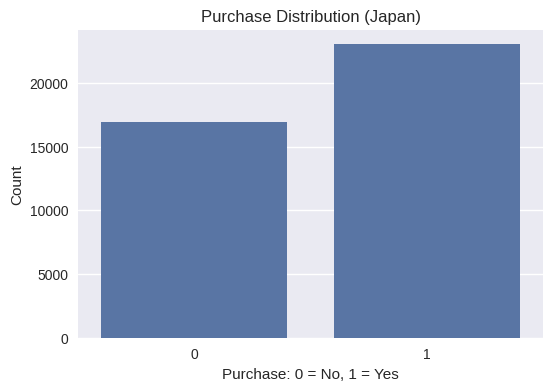

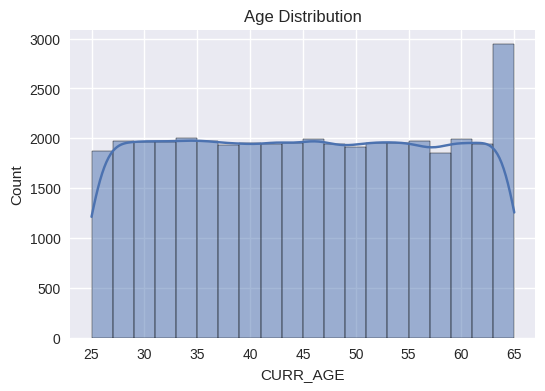

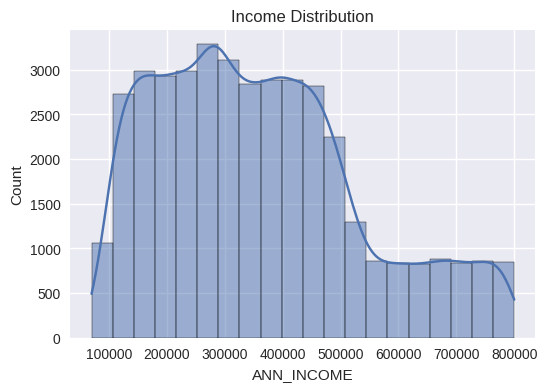

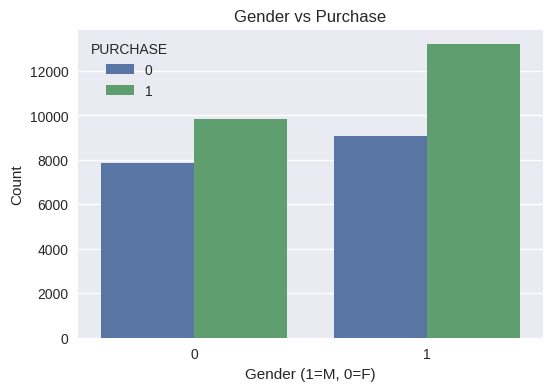

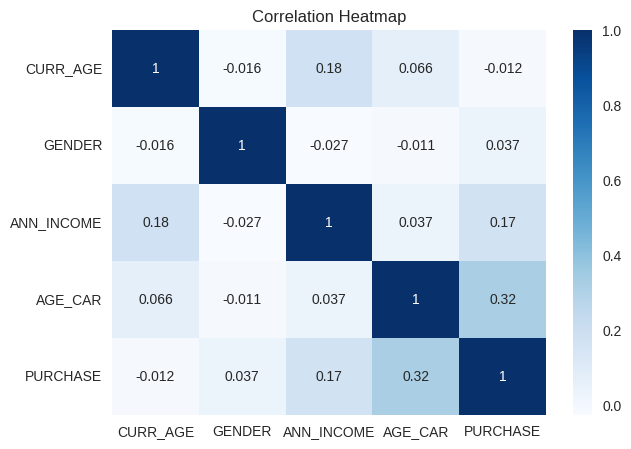

In [ ]:
# --------------------------
# EDA ON JAPANESE DATASET
# --------------------------

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
# 1) Plot purchase distribution
plt.figure(figsize=(6,4))
sns.countplot(x=japan['PURCHASE'])
plt.title("Purchase Distribution (Japan)")
plt.xlabel("Purchase: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()
# 2) Age distribution
plt.figure(figsize=(6,4))
sns.histplot(japan['CURR_AGE'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()
# 3) Income distribution
plt.figure(figsize=(6,4))
sns.histplot(japan['ANN_INCOME'], bins=20, kde=True)
plt.title("Income Distribution")
plt.show()
# 4) Gender vs Purchase
plt.figure(figsize=(6,4))
sns.countplot(x='GENDER', hue='PURCHASE', data=japan)
plt.title("Gender vs Purchase")
plt.xlabel("Gender (1=M, 0=F)")
plt.ylabel("Count")
plt.show()
 5) Correlation Heatmap (Drop non-numeric columns first)
japan_corr = japan.drop(['ID'], axis=1).corr()

plt.figure(figsize=(7,5))
sns.heatmap(japan_corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --------------------------
# FEATURES & TARGET
# --------------------------

X = japan.drop(['ID', 'PURCHASE'], axis=1)
y = japan['PURCHASE']

# --------------------------
# TRAIN-TEST SPLIT
# --------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --------------------------
# MODEL TRAINING
# --------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# --------------------------
# PREDICT
# --------------------------

y_pred = model.predict(X_test)

# --------------------------
# MODEL EVALUATION
# --------------------------

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6811

Confusion Matrix:
 [[2269 1908]
 [1281 4542]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.54      0.59      4177
           1       0.70      0.78      0.74      5823

    accuracy                           0.68     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.68      0.68      0.68     10000



In [ ]:
# Extract coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coeff_df


,Feature,Coefficient
0,CURR_AGE,-0.010969
1,GENDER,0.240319
2,ANN_INCOME,0.000002
3,AGE_CAR,0.004147


In [ ]:
# --------------------------
# PREPARE INDIAN DATA FOR PREDICTION
# --------------------------

# Make sure Indian dataset has same features as Japanese features
# Japanese features: CURR_AGE, GENDER, ANN_INCOME, AGE_CAR

# India dataset does NOT have AGE_CAR, so we approximate or fill with median from Japan
india['AGE_CAR'] = japan['AGE_CAR'].median()

# Select same feature order as model
india_features = india[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR']]

# --------------------------
# PREDICT PURCHASE PROBABILITY
# --------------------------

india['Predicted_Purchase'] = model.predict(india_features)

# Count potential buyers
potential_buyers = india['Predicted_Purchase'].sum()

print("Total Potential Indian Customers:", potential_buyers)


Total Potential Indian Customers: 69482


In [ ]:
required = 12000
predicted = 69482   # you can also use: predicted = potential_buyers

if predicted >= required:
    print("✔ Decision: ABG Motors SHOULD enter the Indian market.")
    print(f"✔ Predicted buyers ({predicted}) exceed the required {required}.")
else:
    print("✘ Decision: ABG Motors SHOULD NOT enter the Indian market.")
    print(f"✘ Predicted buyers ({predicted}) do NOT meet the required {required}.")


✔ Decision: ABG Motors SHOULD enter the Indian market.
✔ Predicted buyers (69482) exceed the required 12000.
